In [3]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

### Load FM Recorded I/Q

In [7]:
sample_rate_hz: float = 1.024e6 / 5.0
print(f"Sample Rate: {sample_rate_hz/1e3} kHz")

Sample Rate: 204.8 kHz


In [5]:
root = Path("data/fm-iq/")
signals = []
for fil in root.glob("*.npy"):
    signal = np.load(fil)
    signal.astype(np.complex64)
    signals.append(signal)
    print(signal.shape)

(12288000,)
(12288000,)
(12288000,)
(6144000,)
(12288000,)
(12288000,)


### Plot Data

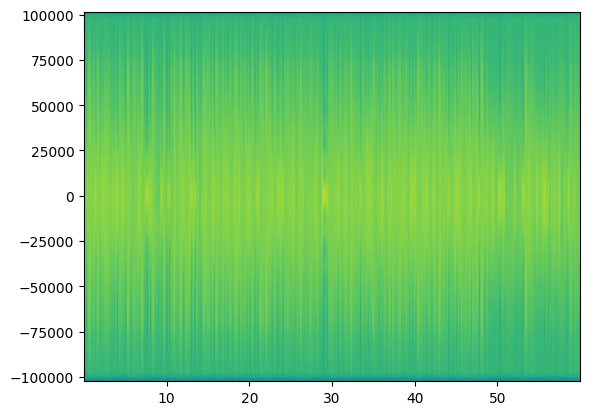

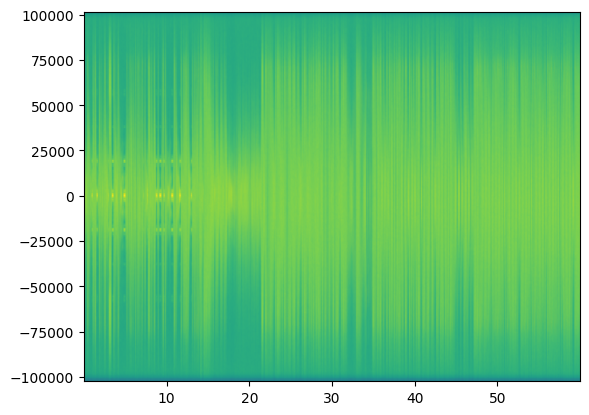

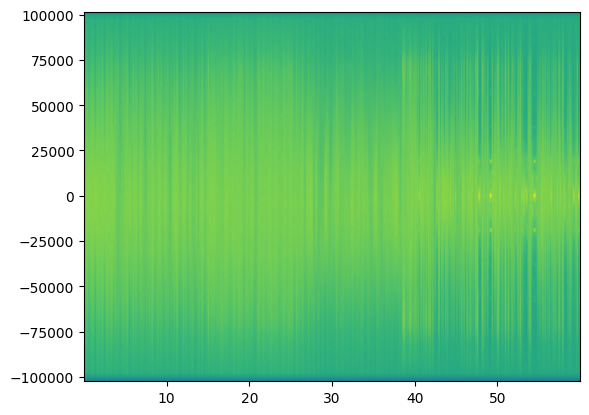

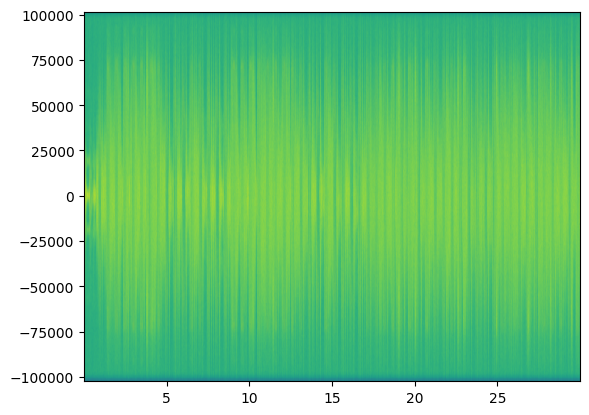

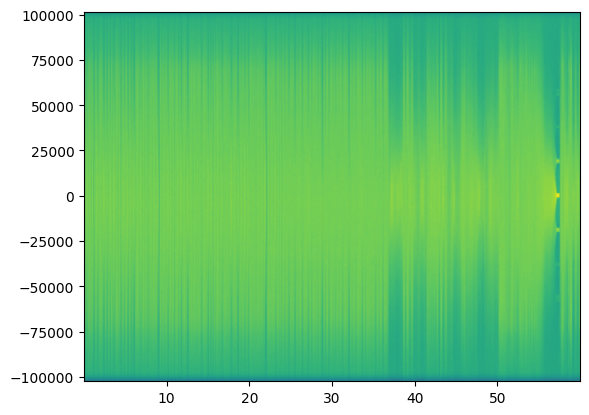

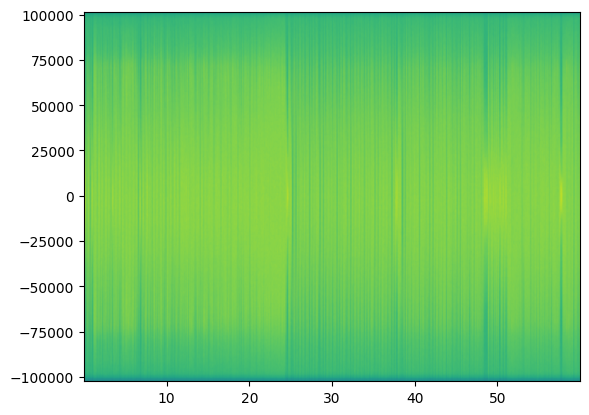

In [15]:
for signal in signals:
    plt.figure()
    _ = plt.specgram(signal, Fs=sample_rate_hz)

### Demodulate FM

In [8]:
from scipy.signal import resample_poly, firwin

In [10]:
import soundfile as sf

In [12]:
audio_sample_rate_hz: float = 44.1e3

In [13]:
def demodulate_fm(
    signal: np.ndarray, 
    sample_rate_hz: float,
    audio_sample_rate_hz: float,
) -> np.ndarray:
    phase = np.unwrap(np.angle(signal))
    freq = np.diff(phase)
    
    h = firwin(512, audio_sample_rate_hz / sample_rate_hz)
    filter_freq = np.convolve(freq, h, mode="same")
    
    freq_downsampled = resample_poly(filter_freq, audio_sample_rate_hz, sample_rate_hz)
    freq_downsampled /= np.abs(freq_downsampled).max()
    
    return freq_downsampled.astype(np.float32)

In [14]:
for sidx, signal in enumerate(signals):
    sf.write(
        f"{sidx}.wav", 
        demodulate_fm(signal, sample_rate_hz, audio_sample_rate_hz), 
        int(audio_sample_rate_hz)
    )